# Local YOLO Inference (Mac MPS Optimized)
This notebook runs your downloaded `best.pt` model locally on your Mac's GPU.

✅ Loading model from yolo_small_v3.pt...
🚀 Running fast inference on Test_Images/image_2.png...

image 1/1 /Users/pavanreddy/Epilogue/YOLO_Inference/Test_Images/image_2.png: 448x640 1 curb, 4 poles, 1 Lane, 7 Speed_Breakers, 11.4ms
Speed: 2.0ms preprocess, 11.4ms inference, 71.3ms postprocess per image at shape (1, 3, 448, 640)


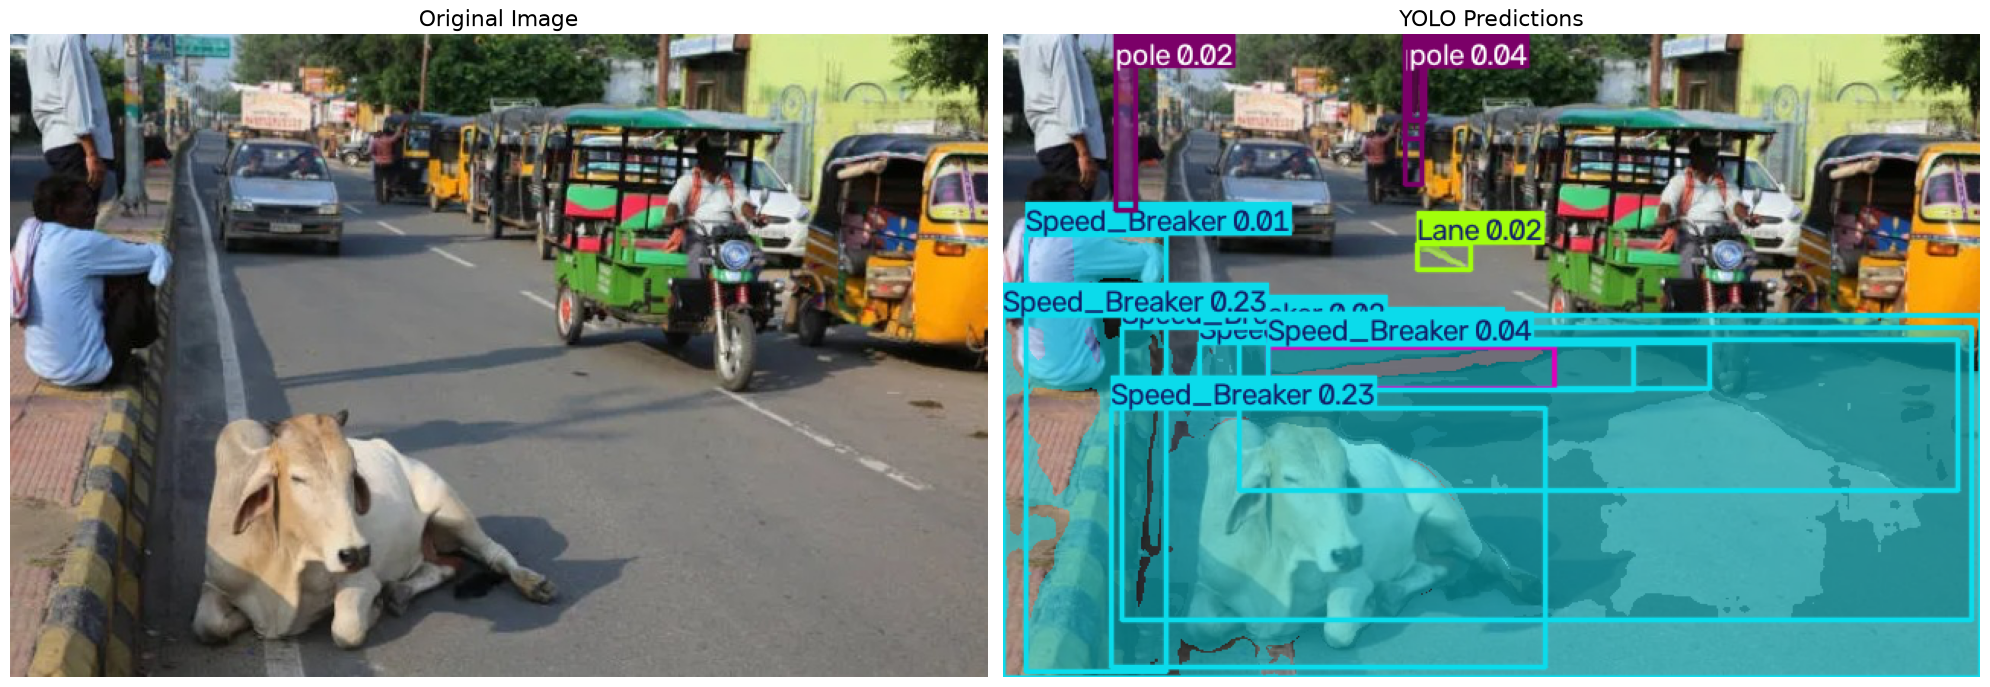

In [5]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Define paths
# Make sure to put your best.pt file and test image in the same folder as this notebook,
# or update these paths to point to them!
model_path = 'yolo_small_v3.pt'
image_path = 'Test_Images/image_2.png'

if not os.path.exists(model_path):
    print(f"❌ Could not find model at '{model_path}'! Please make sure you downloaded it here.")
elif not os.path.exists(image_path):
    print(f"❌ Could not find image at '{image_path}'! Please put a test image here.")
else:
    # 2. Load Model
    print(f"✅ Loading model from {model_path}...")
    model = YOLO(model_path)
    
    # 3. Run Inference using Apple Metal (mps) for fast local GPU processing
    print(f"🚀 Running fast inference on {image_path}...")
    results = model.predict(source=image_path, conf=0.01, imgsz=640, device='mps')
    
    # 4. Generate annotated image
    annotated_img = results[0].plot()
    
    # 5. Display Original vs Prediction side-by-side
    original_img = cv2.imread(image_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    plt.title("Original Image", fontsize=16)
    plt.imshow(original_img)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("YOLO Predictions", fontsize=16)
    plt.imshow(annotated_img)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()